In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak

In [2]:
from pathlib import Path
map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

In [3]:
dfs_evt,lts_evt = {},{}

dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
dfs_evt["r060"], lts_evt["r060"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r060",
    "phy",
    ["ch002"],
)
dfs_evt["r038"], lts_evt["r038"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p00",
    "r038",
    "phy",
    ["ch002"],
)


In [4]:
# masks for physical events, which are defined as events with A_max_mw_o_E_fix_Classifier < 3, Iasy < 0, and not pulser or muon events, and valid waveform.
r059_masks = ((dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& ~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
r038_masks = ((dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r038']['ch002'].Iasy<0)
& ~(dfs_evt['r038']['ch002'].is_pulser)            
& ~(dfs_evt['r038']['ch002'].is_muon)
& (dfs_evt['r038']['ch002'].is_valid_waveform)
)
r060_masks = ((dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r060']['ch002'].Iasy<0)
& ~(dfs_evt['r060']['ch002'].is_pulser)            
& ~(dfs_evt['r060']['ch002'].is_muon)
& (dfs_evt['r060']['ch002'].is_valid_waveform)
)
# for the HE events, we want to select only the muon events, and exclude pulser events.
r059_he_masks = (
~(dfs_evt['r059']['ch002'].is_pulser)            
& (dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
)
r038_he_masks = (
~(dfs_evt['r038']['ch002'].is_pulser)            
& (dfs_evt['r038']['ch002'].is_muon)
& (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r038']['ch002'].Iasy<0)
)
r060_he_masks = (
~(dfs_evt['r060']['ch002'].is_pulser)            
& (dfs_evt['r060']['ch002'].is_muon)
& (dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r060']['ch002'].Iasy<0)
)

r059_argon_mask = (dfs_evt['r059']['ch002'].is_lar_vetoed)
r060_argon_mask = (dfs_evt['r060']['ch002'].is_lar_vetoed)
argon_mask = ak.concatenate([r059_argon_mask,r060_argon_mask])

In [5]:
best_candidates = ['s100ns_mw5','s300ns_mw5','s300ns_mw7','s500ns_mw3','s700ns_mw3']


In [6]:
import tol_colors as tc
cset = tc.bright
cset2 = tc.vibrant
cset.blue
cset.cyan


'#66CCEE'

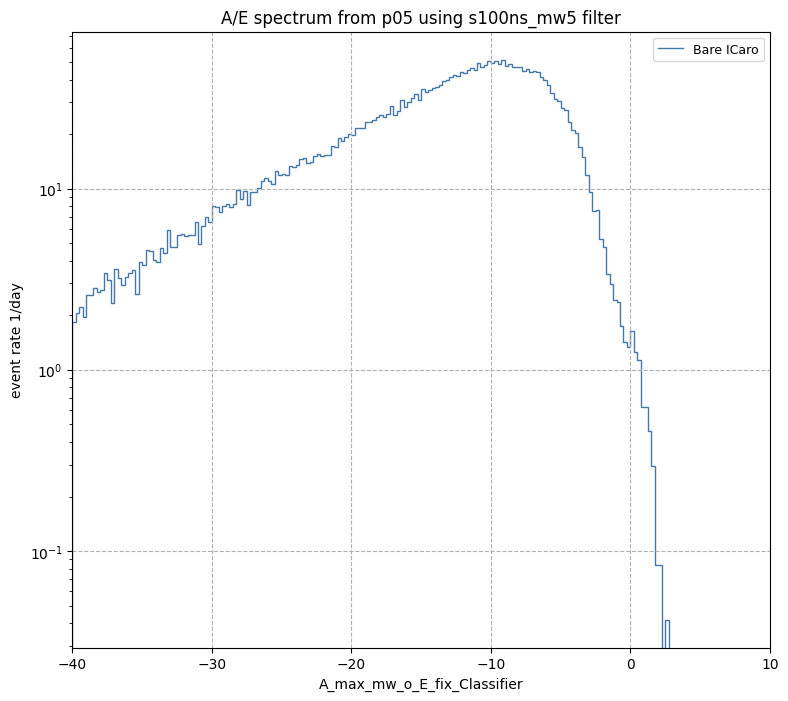

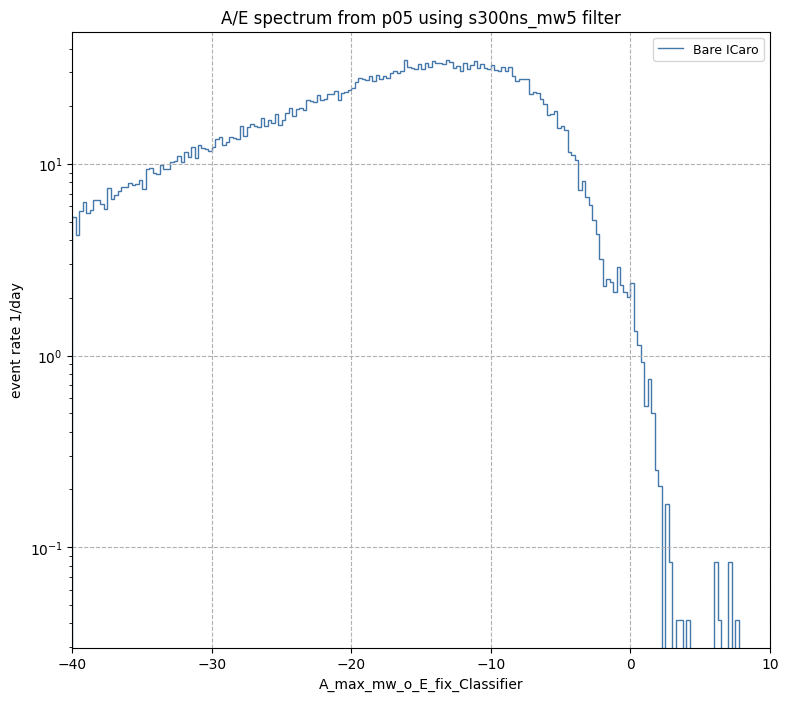

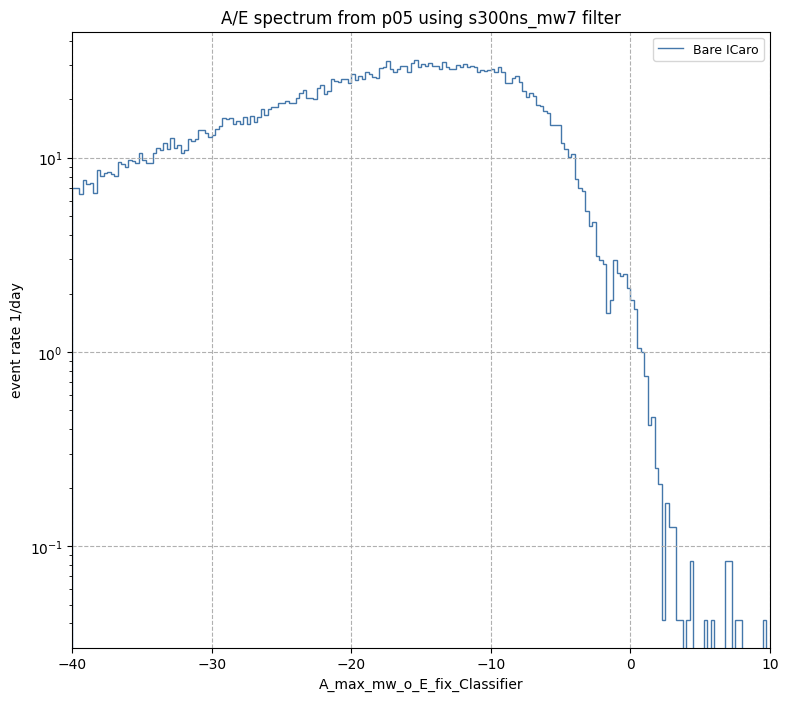

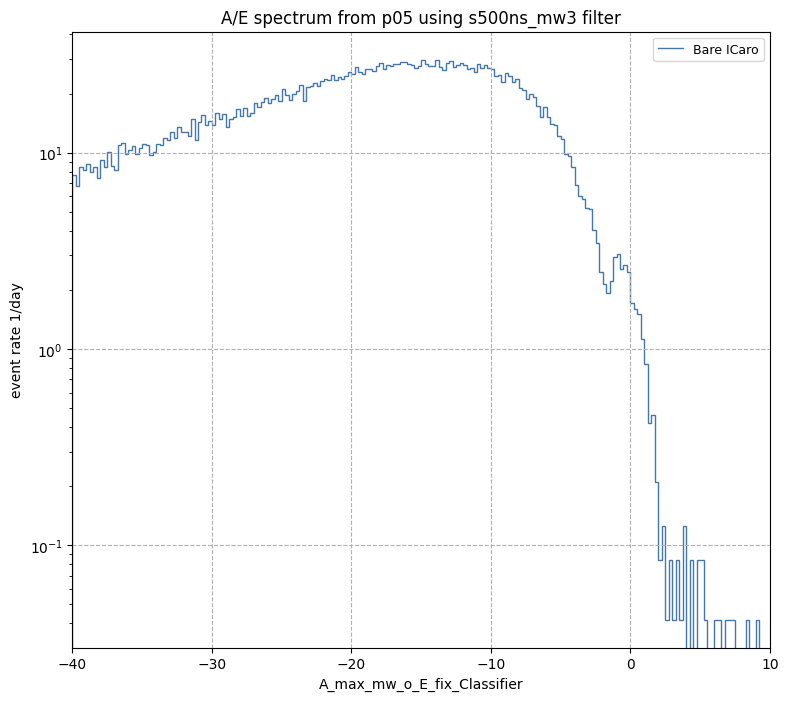

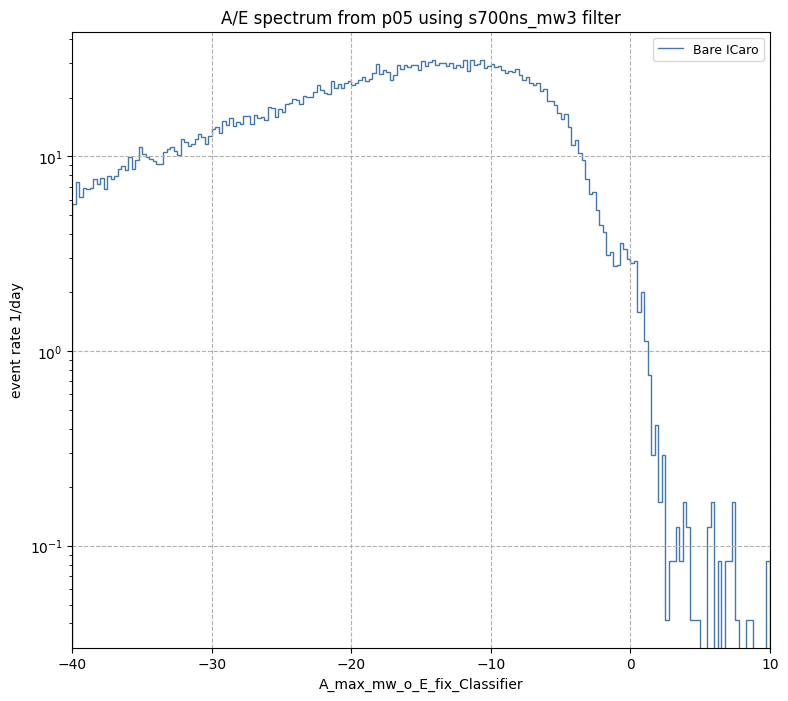

In [7]:
for candidate in best_candidates:
    dfs_sit_candidate, lts_sit_candidate = {}, {}
    dfs_sit_candidate["r038"], lts_sit_candidate["r038"] = dataloader.load_lh5_run(
        ["ch002/hit"],
        map_path(candidate),
        data_cleaning_path,
        "sit",
        "sp01",
        "p00",
        "r038",
        "phy",
        ["ch002"],
    )
    dfs_sit_candidate["r059"], lts_sit_candidate["r059"] = dataloader.load_lh5_run(
        ["ch002/hit"],
        map_path(candidate),
        data_cleaning_path,
        "sit",
        "sp01",
        "p05",
        "r059",
        "phy",
        ["ch002"],
    )
    dfs_sit_candidate["r060"], lts_sit_candidate["r060"] = dataloader.load_lh5_run(
        ["ch002/hit"],
        map_path(candidate),
        data_cleaning_path,
        "sit",
        "sp01",
        "p05",
        "r060",
        "phy",
        ["ch002"],
    )
    gamma_r059 = ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
            ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
            ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<2424.3+5))
    gamma_r038 = ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
            ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
            ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<2424.3+5))
    gamma_r060 = ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
            ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
            ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<2424.3+5))
    candidate_roi_mask_r038 = (
    (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 1839)
    & (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 2239)
    & ~(gamma_r038) 
    )
    candidate_roi_mask_r059 = (
    (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 1839)
    & (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 2239)
    & ~(gamma_r059)
    )
    candidate_roi_mask_r060 = (
    (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 1839)
    & (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 2239)
    & ~(gamma_r060)
    )
    candidate_he_mask_r038 = (
    (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 6000)
    & (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 10000)
    )
    candidate_he_mask_r059 = (
    (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 6000)
    & (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 10000)
    )
    candidate_he_mask_r060 = (
    (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 6000)
    & (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 10000)
    )
    
    sec_to_day = 1 / (60 * 60 * 24)
    
    df_bg = dfs_sit_candidate["r038"]["ch002"]
    mask_bg = r038_masks & candidate_roi_mask_r038
    mask_low_cut_bg = mask_bg & df_bg.A_max_mw_o_E_fix_Low_Cut

    df_phy_r059 = dfs_sit_candidate["r059"]["ch002"]
    mask_phy_059 = r059_masks & candidate_roi_mask_r059
    mask_low_cut_059 = mask_phy_059 & df_phy_r059.A_max_mw_o_E_fix_Low_Cut

    # total = len(df_phy_r059[mask_phy])
    df_phy_r060 = dfs_sit_candidate["r060"]["ch002"]
    mask_phy_060 = r060_masks & candidate_roi_mask_r060
    mask_low_cut_060 = mask_phy_060 & df_phy_r060.A_max_mw_o_E_fix_Low_Cut

    aoe_phy_signal = ak.concatenate([df_phy_r059["A_max_mw_o_E_fix_Classifier"], df_phy_r060["A_max_mw_o_E_fix_Classifier"]])
    phy_signal_mask = ak.concatenate([mask_phy_059, mask_phy_060])
    phy_signal_low_cut_mask = ak.concatenate([mask_low_cut_059, mask_low_cut_060])
    xrange = (-40, 10)
    nbins = 200
    fig, ax =plt.subplots(figsize=(9, 8))

    vals, edges = np.histogram(aoe_phy_signal[phy_signal_mask], bins=nbins, range=xrange)
    vals = vals/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

    # vals_2, edges_2 = np.histogram(aoe_phy_signal[phy_signal_low_cut_mask], bins=nbins, range=xrange)
    # vals_2 = vals_2/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

    vals_3, edges_3 = np.histogram(df_bg[mask_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
    vals_3 = vals_3/lts_sit_candidate["r038"]/sec_to_day

    # vals_4, edges_4 = np.histogram(df_bg[mask_low_cut_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
    # vals_4 = vals_4/lts_sit_candidate["r038"]/sec_to_day

    vals_5, edges_5 = np.histogram(aoe_phy_signal[phy_signal_mask&~argon_mask], bins=nbins, range=xrange)
    vals_5 = vals_5/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

    # ax.stairs(vals, edges,fill=False,alpha=1,baseline=None)
    ax.set_yscale("log")
    ax.set_xlim(xrange)
    # ax.stairs(vals, edges,fill=True,alpha=1,color='#66CCEE')
    ax.stairs(vals_5,edges_5,fill=False,alpha=1,color=cset.blue)
    # ax.stairs(vals_3, edges_3, fill=False,alpha=1,color="red")
    plt.legend(["Bare ICaro","...survived argon veto", "Background"], loc="upper right",fontsize=9)
    plt.title("A/E spectrum from p05 using " + candidate+ ' filter')
    plt.ylabel("event rate 1/day")
    plt.xlabel("A_max_mw_o_E_fix_Classifier")
    plt.grid(linestyle='--')
    plt.show()
    # sf = accepted/total
    # print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")


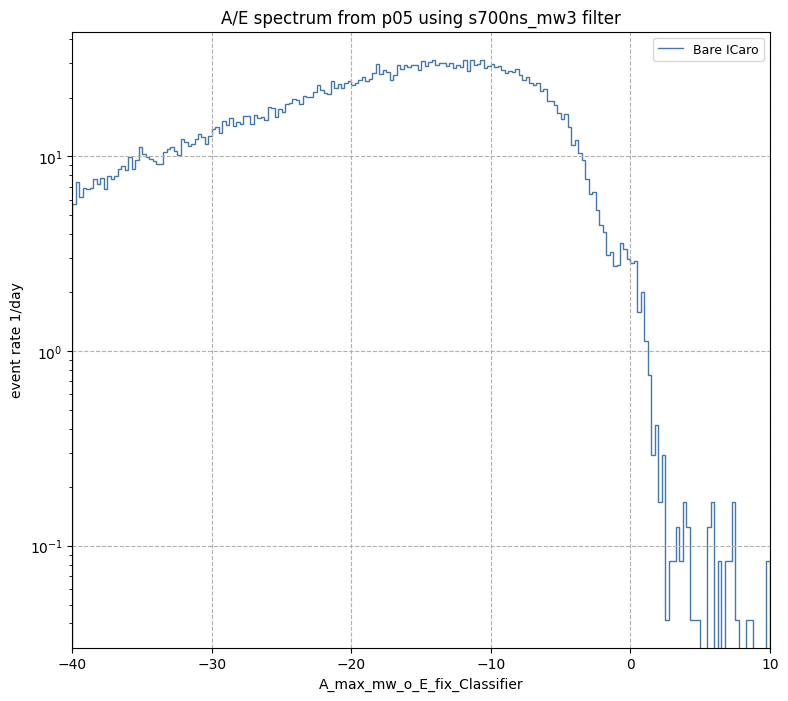

In [8]:
sec_to_day = 1 / (60 * 60 * 24)
df_bg = dfs_sit_candidate["r038"]["ch002"]
mask_bg = r038_masks & candidate_roi_mask_r038
mask_low_cut_bg = mask_bg & df_bg.A_max_mw_o_E_fix_Low_Cut

df_phy_r059 = dfs_sit_candidate["r059"]["ch002"]
mask_phy_059 = r059_masks & candidate_roi_mask_r059
mask_low_cut_059 = mask_phy_059 & df_phy_r059.A_max_mw_o_E_fix_Low_Cut

# total = len(df_phy_r059[mask_phy])
df_phy_r060 = dfs_sit_candidate["r060"]["ch002"]
mask_phy_060 = r060_masks & candidate_roi_mask_r060
mask_low_cut_060 = mask_phy_060 & df_phy_r060.A_max_mw_o_E_fix_Low_Cut

aoe_phy_signal = ak.concatenate([df_phy_r059["A_max_mw_o_E_fix_Classifier"], df_phy_r060["A_max_mw_o_E_fix_Classifier"]])
phy_signal_mask = ak.concatenate([mask_phy_059, mask_phy_060])
phy_signal_low_cut_mask = ak.concatenate([mask_low_cut_059, mask_low_cut_060])
xrange = (-40, 10)
nbins = 200
fig, ax =plt.subplots(figsize=(9, 8))

vals, edges = np.histogram(aoe_phy_signal[phy_signal_mask], bins=nbins, range=xrange)
vals = vals/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

# vals_2, edges_2 = np.histogram(aoe_phy_signal[phy_signal_low_cut_mask], bins=nbins, range=xrange)
# vals_2 = vals_2/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

vals_3, edges_3 = np.histogram(df_bg[mask_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
vals_3 = vals_3/lts_sit_candidate["r038"]/sec_to_day

# vals_4, edges_4 = np.histogram(df_bg[mask_low_cut_bg]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
# vals_4 = vals_4/lts_sit_candidate["r038"]/sec_to_day

vals_5, edges_5 = np.histogram(aoe_phy_signal[phy_signal_mask&~argon_mask], bins=nbins, range=xrange)
vals_5 = vals_5/(lts_sit_candidate["r059"]+lts_sit_candidate["r060"])/sec_to_day

# ax.stairs(vals, edges,fill=False,alpha=1,baseline=None)
ax.set_yscale("log")
ax.set_xlim(xrange)
# ax.stairs(vals, edges,fill=True,alpha=1,color='#66CCEE')
ax.stairs(vals_5,edges_5,fill=False,alpha=1,color=cset.blue)
# ax.stairs(vals_3, edges_3, fill=False,alpha=1,color="red")
plt.legend(["Bare ICaro","...survived argon veto", "Background"], loc="upper right",fontsize=9)
plt.title("A/E spectrum from p05 using " + candidate+ ' filter')
plt.ylabel("event rate 1/day")
plt.xlabel("A_max_mw_o_E_fix_Classifier")
plt.grid(linestyle='--')
# sf = accepted/total
# print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")
